In [1]:
import STAGATE_pyG
import os
import pandas as pd
import scanpy as sc
import torch
torch.set_default_device('mps')

In [6]:
def run_stagate(dsetname):
    os.makedirs(f'_embeddings', exist_ok=True)
    d = sc.read_h5ad(f'_data/{dsetname}/100u_spots.h5ad')
    print(d.shape)
    
    split_samples = {}
    for sid in d.obs.sid.unique():
        myd = d[d.obs.sid == sid].copy()
        STAGATE_pyG.Cal_Spatial_Net(myd, rad_cutoff=150)
        split_samples[sid] = myd

    allsamples = sc.concat([d for d in split_samples.values()], keys=None)
    allsamples.uns['Spatial_Net'] = pd.concat([
        d.uns['Spatial_Net'] for d in split_samples.values()])
    STAGATE_pyG.Stats_Spatial_Net(allsamples)

    allsamples = STAGATE_pyG.train_STAGATE(allsamples, n_epochs=1000)
    sc.pp.neighbors(allsamples, use_rep='STAGATE')
    sc.tl.umap(allsamples)
    sc.tl.leiden(allsamples, resolution=1, key_added='leiden_1')

    allsamples.write(f'_embeddings/{dsetname}_stagate_noharm.h5ad')

(366976, 8)
------Calculating spatial graph...
The graph contains 155896 edges, 19719 cells.
7.9059 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 228498 edges, 28845 cells.
7.9216 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 193636 edges, 24806 cells.
7.8060 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 60962 edges, 7930 cells.
7.6875 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 7930 edges, 1046 cells.
7.5813 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 22436 edges, 2955 cells.
7.5926 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 61984 edges, 8000 cells.
7.7480 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 29826 edges, 3880 cells.
7.6871 neighbors per cell on average.
------Calculating spatial graph...
The graph co

/Users/yakir/miniconda3/envs/stagate/lib/python3.12/site-packages/STAGATE_pyG-1.0.0-py3.12.egg/STAGATE_pyG/utils.py:194: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['Spatial_Net']['Cell1']))
/Users/yakir/miniconda3/envs/stagate/lib/python3.12/site-packages/STAGATE_pyG-1.0.0-py3.12.egg/STAGATE_pyG/utils.py:194: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['Spatial_Net']['Cell1']))


Size of Input:  (366976, 8)


100%|██████████| 1000/1000 [3:05:53<00:00, 11.15s/it]  


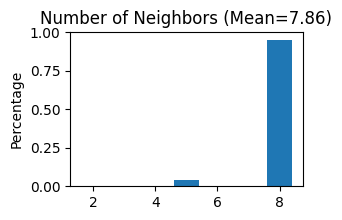

In [7]:
run_stagate('RA')

(51408, 80)
------Calculating spatial graph...
The graph contains 9376 edges, 1224 cells.
7.6601 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 9376 edges, 1224 cells.
7.6601 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 9376 edges, 1224 cells.
7.6601 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 9376 edges, 1224 cells.
7.6601 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 9376 edges, 1224 cells.
7.6601 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 9376 edges, 1224 cells.
7.6601 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 9376 edges, 1224 cells.
7.6601 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 9376 edges, 1224 cells.
7.6601 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 9376 e

/Users/yakir/miniconda3/envs/stagate/lib/python3.12/site-packages/STAGATE_pyG-1.0.0-py3.12.egg/STAGATE_pyG/utils.py:194: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['Spatial_Net']['Cell1']))
/Users/yakir/miniconda3/envs/stagate/lib/python3.12/site-packages/STAGATE_pyG-1.0.0-py3.12.egg/STAGATE_pyG/utils.py:194: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['Spatial_Net']['Cell1']))


The graph contains 9376 edges, 1224 cells.
7.6601 neighbors per cell on average.
Size of Input:  (51408, 80)


100%|██████████| 1000/1000 [21:49<00:00,  1.31s/it]


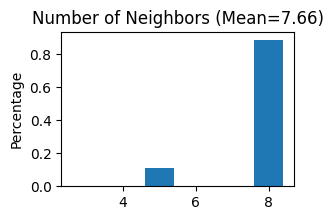

In [8]:
run_stagate('UC')

(200115, 140)
------Calculating spatial graph...
The graph contains 16546 edges, 2176 cells.
7.6039 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 19264 edges, 2564 cells.
7.5133 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 12380 edges, 1693 cells.
7.3125 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 12384 edges, 1763 cells.
7.0244 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 17504 edges, 2286 cells.
7.6570 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 16022 edges, 2106 cells.
7.6078 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 26356 edges, 3503 cells.
7.5238 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 15940 edges, 2170 cells.
7.3456 neighbors per cell on average.
------Calculating spatial graph...
The graph conta

/Users/yakir/miniconda3/envs/stagate/lib/python3.12/site-packages/STAGATE_pyG-1.0.0-py3.12.egg/STAGATE_pyG/utils.py:194: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['Spatial_Net']['Cell1']))
/Users/yakir/miniconda3/envs/stagate/lib/python3.12/site-packages/STAGATE_pyG-1.0.0-py3.12.egg/STAGATE_pyG/utils.py:194: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['Spatial_Net']['Cell1']))


Size of Input:  (200115, 140)


100%|██████████| 1000/1000 [1:19:14<00:00,  4.75s/it]


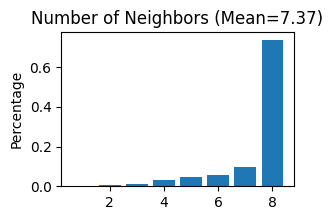

In [9]:
run_stagate('ALZ')